# CUSTOMER BEHAVIOUR AND CREDIT ANALYSIS

### INTRODUCTION

This study explores customer behaviour across MoPhones’ credit portfolio using transactional, demographic, and NPS survey data. The analysis focuses on understanding repayment patterns, customer segmentation, and how demographic factors such as income, age, and employment duration influence credit performance and customer experience.

By integrating credit snapshots with customer and survey data, the analysis aims to generate actionable insights that support improved credit monitoring, risk assessment, and customer retention strategies.


In [194]:
#load data
import pandas as pd
df_nps = pd.read_excel(r"C:\Users\Faith Mutio\Downloads\NPS Data.xlsx")
df_credit = pd.read_excel (r"C:\Users\Faith Mutio\Downloads\Credit Data 2025.xlsx")
df_sales = pd.read_excel (r"C:\Users\Faith Mutio\Downloads\Sales and Customer Data\Sales and Customer Data.xlsx")

In [195]:
#preview loaded data
df_nps.head()

,Submission ID,Respondent ID,Submitted at,Loan Id,"Using a scale from 0 (not likely) to 10 (very likely), how likely are you to recommend MoPhones to friends or family?",What is the main reason for your score?,What is one thing we could do to improve your experience with us?,Are you happy with the quality and performance of your MoPhones device?,Are you happy with the service and support provided by MoPhones?,Have you ever experienced a delay in your payment reflecting in your Mophones account?,Have you ever had difficulty getting assistance from MoPhones customer support when needed?,(If Yes) – Please describe the challenge you faced and how we can improve your experience.,Have you experienced any battery-related issues with your MoPhones device?,Have you used the MoPhones app (MoApp) to manage your account or make payments?,Which communication channel do you prefer when contacting MoPhones for inquiries or support?,Have you ever had your phone lock despite making a payment on time?,Any other Feedback?
0,BzK4Q11,k4z1Y6,2025-04-22 15:15:00,rec2FCxHhqXw6aKRU,6.0,NaN,NaN,Yes,Yes,Yes,Yes,Unlocking my phone,No,"Yes, and I am satisfied with the MoApp",MoPhones App,Yes,NaN
1,b59V45Z,AY9GMk,2025-04-22 15:18:00,recQcLWbPcep18Wdw,10.0,NaN,NaN,Yes,Yes,No,No,Response team always on time,No,"Yes, and I am satisfied with the MoApp",Free SMS – 25044,No,Would like to upgrade once I'm done with this ...
2,GxKvYKO,eGz8Ek,2025-04-22 15:31:00,recei9UEU0e5F9HuG,5.0,NaN,NaN,No,No,No,Yes,I bought a Samsung A42 which has fingerprint l...,No,"Yes, and I am satisfied with the MoApp",Phone Call – +254 728 444 442 or +254 709 924 404,Yes,Good service and efficient response
3,A7KP49z,LjOx7j,2025-04-22 15:40:00,recosDWAJvWzAKgLv,1.0,NaN,NaN,No,No,Yes,Yes,Delays,Yes,"Yes, but I am not satisfied with the MoApp",NaN,NaN,NaN
4,81zo6pr,7YE0RR,2025-04-22 15:40:00,recTJng0Mj0dJP1kv,1.0,NaN,NaN,No,No,Yes,Yes,Not satisfied with my phone,Yes,"Yes, but I am not satisfied with the MoApp",MoPhones App,Yes,Not satisfied with my phone


In [196]:
df_credit.head()

,LOAN_ID,DATE,CUSTOMER_AGE,TOTAL_PAID,TOTAL_DUE_TODAY,BALANCE,DAYS_PAST_DUE,CLOSING_BALANCE,ADVANCE,BALANCE_DUE_TO_DATE,...,PREPAYMENT_AMOUNT,DEPOSIT,WEEKLY_RATE,CREDIT_EXPIRY,NEXT_INVOICE_DATE,DISCOUNT,OVERPAYMENT_AMOUNT,MAX_PAYMENT_DATE,INITIAL_PAY,TOTAL_PAID_WITH_ADJUSTMENTS_15D
0,recnBZuKLsWCIm3cW,2025-01-01,102,20639,21649.0,38380.0,4,38380.0,0.0,-1010.0,...,0,6499.0,1010.0,2024-12-28,2025-01-04,0.0,0.0,2025-01-07,7509,20639
1,recwUTOdXSW5kSAed,2025-01-01,211,48101,49419.0,29038.0,0,0.0,0.0,-1318.0,...,0,8499.0,1320.0,2024-12-31,2025-01-07,0.0,0.0,2025-10-10,9819,48101
2,recPCzNo2d9qK1VB3,2025-01-01,22,52999,52999.0,0.0,0,0.0,0.0,0.0,...,0,13699.0,1580.0,2024-12-17,2025-01-07,0.0,0.0,2024-12-10,52999,52999
3,rec98Vut24ajzNeWL,2025-01-01,145,21899,48249.0,80600.0,110,80600.0,0.0,-26350.0,...,0,11499.0,1750.0,2024-09-13,2025-01-03,0.0,0.0,2024-09-17,13249,21899
4,recEmhLuKhmOsEqGl,2025-01-01,271,35719,35419.0,9840.0,0,0.0,300.0,300.0,...,0,4999.0,780.0,2025-01-03,2025-01-03,0.0,0.0,2025-04-04,5779,35719


In [197]:
df_sales.head()

,SALE_ID,SALE_DATE,RETURNED,RETURN_DATE,SALE_TYPE,SELLER,CITIZENSHIP,GENDER,DATE OF BIRTH,createdAt UTC,...,BUSINESS_MODEL,LOAN_TERM,PRODUCT_NAME,MODEL,Loan Id,Duration,Received,Persons Received From Total,Banks Received,Paybills Received Others
0,recg9SxxjvTdgP6NC,2025-06-26,False,NaT,Financed,angela Muthini,KENYAN,Male,1998-12-12 00:00:00,2025-06-02T10:48:20.041Z,...,1P1C,12M,Samsung-Note-20-128GB,Note-20,recg9SxxjvTdgP6NC,12.0,169627.61,134720.0,5010.0,17.0
1,rec0P2Z778n8igV9u,2024-07-15,False,NaT,Financed,Divinah Kerubo Nyangenyo,NaN,NaN,NaN,NaN,...,1P1C,12M,Samsung-Galaxy-S22-Ultra-256GB,Galaxy-S22-Ultra,rec0P2Z778n8igV9u,NaN,NaN,NaN,NaN,NaN
2,recbZfItLLouuJj9h,2024-08-15,False,NaT,Financed,Cynthia Mutai,NaN,NaN,NaN,NaN,...,3P1C,12M,Samsung-Galaxy-A15-128GB,Galaxy-A15,recbZfItLLouuJj9h,NaN,NaN,NaN,NaN,NaN
3,recBtxgmMbuLKdANY,2023-05-05,False,NaT,Financed,Simon Ojiambo,NaN,NaN,NaN,NaN,...,1P1C,12M,Samsung-Galaxy-S10-128GB,Galaxy-S10,recBtxgmMbuLKdANY,NaN,NaN,NaN,NaN,NaN
4,recspqipYdXTH1lNV,2025-07-14,False,NaT,Financed,Esther Nduta,KENYAN,Male,1984-02-14T00:00:00+03:00,2025-07-14T09:02:38.714Z,...,3P3C,3M,Samsung-Galaxy-S24-Ultra-512GB,Galaxy-S24-Ultra,recspqipYdXTH1lNV,11.0,396075.43,328776.0,223600.0,44240.0


In [198]:
#clean column names
df_nps.columns = df_nps.columns.str.strip().str.lower().str.replace(' ', '_')
df_credit.columns = df_credit.columns.str.strip().str.lower().str.replace(' ', '_')
df_sales.columns = df_sales.columns.str.strip().str.lower().str.replace(' ', '_')

#preview clean column names
print(df_nps.columns)
print(df_credit.columns)
print(df_sales.columns)

Index(['submission_id', 'respondent_id', 'submitted_at', 'loan_id',
       'using_a_scale_from_0_(not_likely)_to_10_(very_likely),_how_likely_are_you_to_recommend_mophones_to_friends_or_family?',
       'what_is_the_main_reason_for_your_score?',
       'what_is_one_thing_we_could_do_to_improve_your_experience_with_us?',
       'are_you_happy_with_the_quality_and_performance_of_your_mophones_device?',
       'are_you_happy_with_the_service_and_support_provided_by_mophones?',
       'have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?',
       'have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?',
       '(if_yes)_–_please_describe_the_challenge_you_faced_and_how_we_can_improve_your_experience.',
       'have_you_experienced_any_battery-related_issues_with_your_mophones_device?',
       'have_you_used_the_mophones_app_(moapp)_to_manage_your_account_or_make_payments?',
       'which_communication_channel_do_you_pre

## Data Preparation

In [199]:
#join tables

#join sales to credit table
sales_credit = pd.merge(
    df_sales,
    df_credit,
    on="loan_id",
    how="inner",
    suffixes=("_sales", "_credit")
)
#join sales_credit to nps table
merged_data = pd.merge(
    sales_credit,
    df_nps,
    on="loan_id",
    how="inner"
)
#preview merged data
merged_data.head()


,sale_id,sale_date_sales,returned,return_date_sales,sale_type,seller,citizenship,gender,date_of_birth,createdat_utc,...,are_you_happy_with_the_quality_and_performance_of_your_mophones_device?,are_you_happy_with_the_service_and_support_provided_by_mophones?,have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?,have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?,(if_yes)_–_please_describe_the_challenge_you_faced_and_how_we_can_improve_your_experience.,have_you_experienced_any_battery-related_issues_with_your_mophones_device?,have_you_used_the_mophones_app_(moapp)_to_manage_your_account_or_make_payments?,which_communication_channel_do_you_prefer_when_contacting_mophones_for_inquiries_or_support?,have_you_ever_had_your_phone_lock_despite_making_a_payment_on_time?,any_other_feedback?
0,recBpBCJ5IVCjq3qL,2024-10-29,False,NaT,Financed,Juliana Mulumba,KENYAN,Female,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,recBpBCJ5IVCjq3qL,2024-10-29,False,NaT,Financed,Juliana Mulumba,KENYAN,Female,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,recBpBCJ5IVCjq3qL,2024-10-29,False,NaT,Financed,Juliana Mulumba,KENYAN,Female,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,recBpBCJ5IVCjq3qL,2024-10-29,False,NaT,Financed,Juliana Mulumba,KENYAN,Female,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,recBpBCJ5IVCjq3qL,2024-10-29,False,NaT,Financed,Juliana Mulumba,KENYAN,Female,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [200]:
#replace empty fields with N/A
merged_data = merged_data.fillna("N/A")

merged_data.head()

,sale_id,sale_date_sales,returned,return_date_sales,sale_type,seller,citizenship,gender,date_of_birth,createdat_utc,...,are_you_happy_with_the_quality_and_performance_of_your_mophones_device?,are_you_happy_with_the_service_and_support_provided_by_mophones?,have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?,have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?,(if_yes)_–_please_describe_the_challenge_you_faced_and_how_we_can_improve_your_experience.,have_you_experienced_any_battery-related_issues_with_your_mophones_device?,have_you_used_the_mophones_app_(moapp)_to_manage_your_account_or_make_payments?,which_communication_channel_do_you_prefer_when_contacting_mophones_for_inquiries_or_support?,have_you_ever_had_your_phone_lock_despite_making_a_payment_on_time?,any_other_feedback?
0,recBpBCJ5IVCjq3qL,2024-10-29,False,N/A,Financed,Juliana Mulumba,KENYAN,Female,N/A,N/A,...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
1,recBpBCJ5IVCjq3qL,2024-10-29,False,N/A,Financed,Juliana Mulumba,KENYAN,Female,N/A,N/A,...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
2,recBpBCJ5IVCjq3qL,2024-10-29,False,N/A,Financed,Juliana Mulumba,KENYAN,Female,N/A,N/A,...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
3,recBpBCJ5IVCjq3qL,2024-10-29,False,N/A,Financed,Juliana Mulumba,KENYAN,Female,N/A,N/A,...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
4,recBpBCJ5IVCjq3qL,2024-10-29,False,N/A,Financed,Juliana Mulumba,KENYAN,Female,N/A,N/A,...,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


In [201]:
#remove duplicates
#show how many exact duplicate rows exist
print("Total rows before:", len(merged_data))
print("Exact duplicate rows:", merged_data.duplicated().sum())

#remove exact duplicates in place, keep the first occurrence
merged_data.drop_duplicates(keep='first', inplace=True)
merged_data.reset_index(drop=True, inplace=True)

#confirm result
print("Total rows after:", len(merged_data))
print("Exact duplicate rows remaining:", merged_data.duplicated().sum())

Total rows before: 12797
Exact duplicate rows: 0
Total rows after: 12797
Exact duplicate rows remaining: 0


In [202]:
#standardize date formats
import numpy as np

df = merged_data

#normalize common empty markers to actual missing values
_empty_markers = ["N/A", "n/a", "NA", "na", "", None]
df['date_of_birth'] = df['date_of_birth'].replace(_empty_markers, pd.NA)
df['createdat_utc'] = df['createdat_utc'].replace(_empty_markers, pd.NA)

#trim whitespace and ensure string-like for safe parsing
df['date_of_birth'] = df['date_of_birth'].astype("string").str.strip()
df['createdat_utc'] = df['createdat_utc'].astype("string").str.strip()

#parse createdAt timestamps (timezone-aware strings normalized to UTC)
df['createdat_utc'] = pd.to_datetime(df['createdat_utc'], errors='coerce', utc=True)

#parse date_of_birth (supports YYYY-MM-DD and ISO offsets; invalid -> NaT)
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')

#quick preview to confirm parsing
print("dtypes after parsing:")
print(df[['date_of_birth', 'createdat_utc']].dtypes)
print("\nSample parsed values:")
print(df[['date_of_birth', 'createdat_utc']].head(10))

dtypes after parsing:
date_of_birth    datetime64[ns, UTC+03:00]
createdat_utc          datetime64[ns, UTC]
dtype: object

Sample parsed values:
              date_of_birth                    createdat_utc
0                       NaT                              NaT
1                       NaT                              NaT
2                       NaT                              NaT
3                       NaT                              NaT
4                       NaT                              NaT
5 1992-03-02 00:00:00+03:00 2025-01-20 12:18:49.616000+00:00
6 1992-03-02 00:00:00+03:00 2025-01-20 12:18:49.616000+00:00
7 1992-03-02 00:00:00+03:00 2025-01-20 12:18:49.616000+00:00
8 1992-03-02 00:00:00+03:00 2025-01-20 12:18:49.616000+00:00
9 1997-02-28 00:00:00+03:00 2025-04-09 12:40:45.547000+00:00


### Age Band

### Assumptions
1. Reference date - Assume createdat_utc is the reporting date in UTC.
2. DOB format and timezone - Assume date_of_birth is a timezone‑aware or timezone‑naive pandas datetime; invalid or missing DOBs produce NaN age.


In [203]:
#calculate age as at the reporting date
df = merged_data

report_date = None

if report_date is None:
    ref = df['createdat_utc']            # series of datetimes (UTC) or NaT
else:
    ref = pd.to_datetime(report_date, utc=True)

#compute age in whole years (vectorized)
dob = df['date_of_birth']

age_years = (
    ref.dt.year
    - dob.dt.year
    - (
        (ref.dt.month < dob.dt.month)
        | ((ref.dt.month == dob.dt.month) & (ref.dt.day < dob.dt.day))
    )
)

#assign result; keep NaN/NaT where dob or ref is missing
df['age'] = age_years

#optionally convert to integer where non-missing
df['age'] = df['age'].where(df['age'].notna(), np.nan)   # keep NaN for missing
# If you prefer integer and a sentinel for missing:
# df['age_int'] = df['age'].dropna().astype(int)
# df['age'] = df['age'].fillna(-1).astype(int)  # -1 indicates missing

#preview results
print(df[['date_of_birth', 'createdat_utc', 'age']].head())

  date_of_birth createdat_utc  age
0           NaT           NaT  NaN
1           NaT           NaT  NaN
2           NaT           NaT  NaN
3           NaT           NaT  NaN
4           NaT           NaT  NaN


In [204]:
#compute age bands
df = merged_data

#ensure age is numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

#define bins and labels (using the existing age field)
bins = [0, 17, 25, 35, 45, 55, 200]
labels = ['<18', '18–25', '26–35', '36–45', '46–55', '55+']

#create age_band from the numeric age
df['age_band'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

#replace missing bands with a clear marker
df['age_band'] = df['age_band'].cat.add_categories(['N/A']).fillna('N/A')

#quick check
print(df[['age', 'age_band']].head())
print("\nCounts per band:")
print(df['age_band'].value_counts(dropna=False))

   age age_band
0  NaN      N/A
1  NaN      N/A
2  NaN      N/A
3  NaN      N/A
4  NaN      N/A

Counts per band:
age_band
N/A      7280
26–35    2882
18–25    1457
36–45     857
46–55     279
55+        42
<18         0
Name: count, dtype: int64


### Average Monthly Income

### Assumptions
1. Income aggregation - Total income per loan is the sum of the specified income columns; negative or zero durations are treated as missing.
2. Duration units - Assume duration is measured in months.
3. Average interpretation - avg_monthly_income = total received ÷ duration (months), interpreted as average monthly received amount.
4. One row per loan - per_loan contains one row per loan_id with fields total_received, duration, avg_monthly_income, and income_band. This avoids duplicate income bands for the same loan_id.



In [205]:
import numpy as np

#choose income columns explicitly (adjust names)
income_cols = [c for c in ['received','persons_received_from_total','banks_received','paybills_received','others'] if c in merged_data.columns]

#ensure numeric
for c in income_cols:
    merged_data[c] = pd.to_numeric(merged_data[c], errors='coerce')
merged_data['duration'] = pd.to_numeric(merged_data.get('duration', pd.Series(dtype='float')), errors='coerce')

#aggregate per loan_id: sum incomes, take first non-null duration, and keep one row per loan
agg_dict = {c: 'sum' for c in income_cols}
agg_dict['duration'] = lambda x: x.dropna().iloc[0] if x.dropna().shape[0] > 0 else np.nan

per_loan = merged_data.groupby('loan_id', dropna=False, as_index=False).agg(agg_dict)

#compute totals and per-duration average
per_loan['total_received'] = per_loan[income_cols].sum(axis=1, skipna=True)
per_loan.loc[per_loan['duration'] <= 0, 'duration'] = np.nan
per_loan['avg_monthly_income'] = per_loan['total_received'] / per_loan['duration']

#now per_loan has one row per loan_id
print("Per-loan rows:", len(per_loan))
per_loan.head()

Per-loan rows: 3532


,loan_id,received,persons_received_from_total,banks_received,duration,total_received,avg_monthly_income
0,rec01VlZfsRhGD8vI,0.00,0.0,0.0,NaN,0.00,NaN
1,rec02rkeZIYT1p7GK,0.00,0.0,0.0,NaN,0.00,NaN
2,rec037qWdMLkmq19x,4349884.38,3453900.0,3143700.0,6.0,10947484.38,1824580.73
3,rec05XU0EE7hoe6gY,273476.00,187428.0,192280.0,6.0,653184.00,108864.00
4,rec06Jw9u4LbqIul4,2984566.00,2984566.0,1450600.0,12.0,7419732.00,618311.00


In [206]:
#create income band
bins = [-np.inf, 5000, 10000, 20000, 30000, 50000, 100000, 150000, np.inf]
labels = [
    "Below 5,000",
    "5,000 - 9,999",
    "10,000 - 19,999",
    "20,000 - 29,999",
    "30,000 - 49,999",
    "50,000 - 99,999",
    "100,000 - 149,999",
    "150,000+"
]

#use left-inclusive intervals [a, b) so 5,000 falls into "5,000–9,999"
per_loan['income_band'] = pd.cut(
    per_loan['avg_monthly_income'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

#mark loans with missing/invalid avg as 'Unknown'
per_loan['income_band'] = per_loan['income_band'].cat.add_categories(['Unknown'])
per_loan.loc[per_loan['avg_monthly_income'].isna(), 'Band'] = 'Unknown'

#keep only one row per loan_id (per_loan already does this)
print("Per-loan rows:", len(per_loan))
per_loan[['loan_id', 'total_received', 'duration', 'avg_monthly_income', 'income_band']].head()


Per-loan rows: 3532


,loan_id,total_received,duration,avg_monthly_income,income_band
0,rec01VlZfsRhGD8vI,0.00,NaN,NaN,NaN
1,rec02rkeZIYT1p7GK,0.00,NaN,NaN,NaN
2,rec037qWdMLkmq19x,10947484.38,6.0,1824580.73,"150,000+"
3,rec05XU0EE7hoe6gY,653184.00,6.0,108864.00,"100,000 - 149,999"
4,rec06Jw9u4LbqIul4,7419732.00,12.0,618311.00,"150,000+"


## Analysis
### Portfolio Health
**1. Portfolio at Risk (PAR 30) Ratio**

**Purpose**: tracks the overall health of the loan book across snapshots.

**Why this matters operationally**: A rising trend indicates credit policy failure or worsening economic conditions, signaling a need to tighten lending criteria.

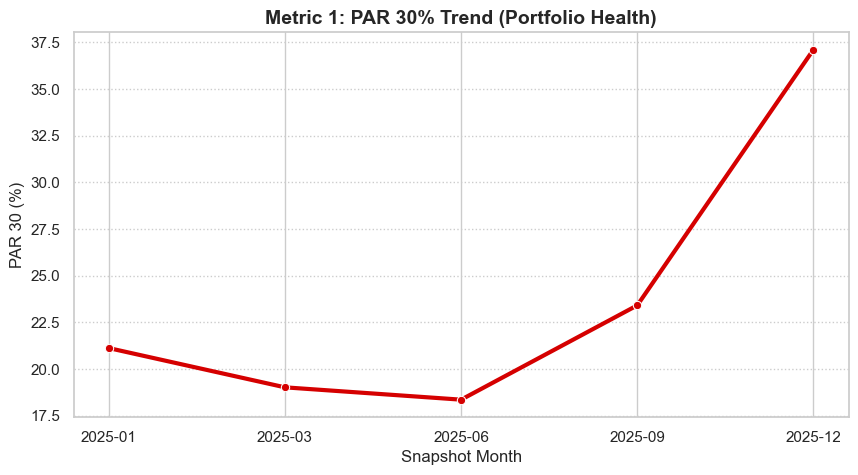

In [207]:
#load necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

#clean & format
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
df['balance'] = pd.to_numeric(df['balance'], errors='coerce').fillna(0)
df['days_past_due'] = pd.to_numeric(df['days_past_due'], errors='coerce').fillna(0)

#group by month and calculate PAR 30 Ratio
par_trend = df.groupby('month', as_index=False).apply(
    lambda x: (x[x['days_past_due'] > 30]['balance'].sum() / x['balance'].sum() * 100) if x['balance'].sum() > 0 else 0,
    include_groups=False
).rename(columns={None: 'PAR30_pct'})

par_trend['month_str'] = par_trend['month'].astype(str)

#plot
plt.figure(figsize=(10, 5))
sns.lineplot(data=par_trend, x='month_str', y='PAR30_pct', marker='o', color='#D50000', linewidth=3)
plt.title('Metric 1: PAR 30% Trend (Portfolio Health)', fontsize=14, fontweight='bold')
plt.ylabel('PAR 30 (%)')
plt.xlabel('Snapshot Month')
plt.grid(axis='y', linestyle=':')
plt.show()

### Insights

1. **Sharp late‑year deterioration** — PAR30 jumps from ~18–19% mid‑year to around ~36–37% by December, signaling a rapid and large increase in delinquency that requires immediate provisioning and intensified collections.  

2. **Reversal after mid‑year improvement** — the portfolio shows improvement through mid‑year before the spike, indicating a recent shock or change in borrower behavior or operations rather than a steady trend.

**Recommendation**: Investigate policy, economic, or process changes around the inflection point.  


**2. Collection Efficiency Index (CEI)**

**Purpose**: Measures how effectively the collection team is recovering money currently due.

**Why this matters operationally**: If CEI is low but PAR is stable, the issue is likely operational (e.g., payment system downtime) rather than a loss of customer ability to pay.

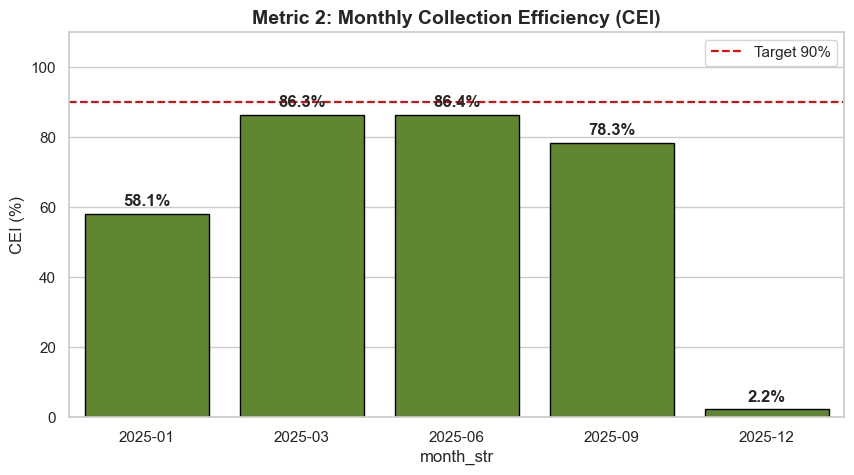

In [208]:
#clean & format
df['payment_amount'] = pd.to_numeric(df['payment_amount'], errors='coerce').fillna(0)
df['expected_payment'] = pd.to_numeric(df['expected_payment'], errors='coerce').fillna(1)
df['month'] = pd.to_datetime(df['date']).dt.to_period('M')

#aggregate monthly collections
cei_stats = df.groupby('month', as_index=False).agg({
    'payment_amount': 'sum',
    'expected_payment': 'sum'
})
cei_stats['CEI_pct'] = (cei_stats['payment_amount'] / cei_stats['expected_payment']) * 100
cei_stats['month_str'] = cei_stats['month'].astype(str)

#plot
plt.figure(figsize=(10, 5))
# Use a bright "Kenyatta-style" green
ax = sns.barplot(data=cei_stats, x='month_str', y='CEI_pct', color="#619423", edgecolor='black')
plt.axhline(90, color='red', linestyle='--', label='Target 90%')

#add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Metric 2: Monthly Collection Efficiency (CEI)', fontsize=14, fontweight='bold')
plt.ylabel('CEI (%)')
plt.ylim(0, 110)
plt.legend()
plt.show()

### Insights
1. **Severe collapse in December** — CEI plunges to ~2%, indicating a near‑total failure of collections in the most recent snapshot.
2. **Consistently below target** — CEI never reaches the 90% target across snapshots, showing chronic underperformance.
3. **High volatility** — Large month‑to‑month swings (58% → 86% → 86% → 78% → 2%) point to operational or channel instability rather than a smooth seasonal pattern.

### Recommendation
- **Medium‑term resilience (1–3 months)**: Add redundancy across payment channels, implement automated retry and reconciliation alerts, tighten monitoring (real‑time CEI dashboard + alert thresholds), and run a pilot to improve collections workflows.

- **Governance & prevention**: set SLA for CEI (e.g., 90% target with 72‑hour incident response), run monthly post‑mortems on any CEI drop >10 pp, and include CEI and channel health in executive reporting.

These steps stop the immediate bleeding, fix root causes, and reduce the chance of recurrence.


**3. Risk Variance by Age Band**

**Purpose**: Identifies specific customer segments where risk behavior differs meaningfully from the average.

**Why this matters operationally**: Identifying a high-risk age band (e.g., 18–25) allows the business to implement "Risk-Based Pricing" or require higher deposits from a specific group.

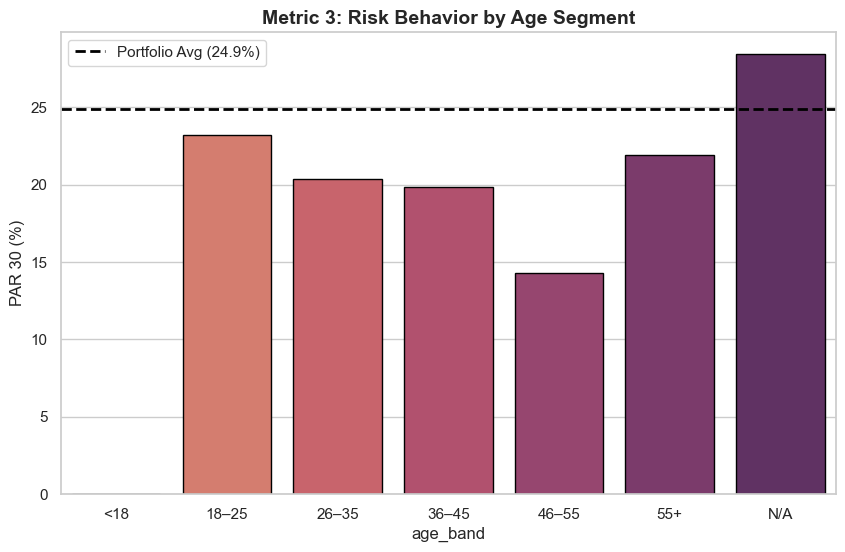

Operational Highlight: Portfolio Average PAR is 24.90%.


In [209]:
#prepare data
df['balance'] = pd.to_numeric(df['balance'], errors='coerce').fillna(0)
df['days_past_due'] = pd.to_numeric(df['days_past_due'], errors='coerce').fillna(0)

#calculate stats
portfolio_avg = (df[df['days_past_due'] > 30]['balance'].sum() / df['balance'].sum()) * 100

age_stats = df.groupby('age_band', observed=False).apply(
    lambda x: (x[x['days_past_due'] > 30]['balance'].sum() / x['balance'].sum() * 100) if x['balance'].sum() > 0 else 0,
    include_groups=False
).reset_index(name='age_par')

#plot
plt.figure(figsize=(10, 6))
sns.barplot(data=age_stats, x='age_band', y='age_par', hue='age_band', palette='flare', legend=False, edgecolor='black')

plt.axhline(portfolio_avg, color='black', linestyle='--', linewidth=2, label=f'Portfolio Avg ({portfolio_avg:.1f}%)')

plt.title('Metric 3: Risk Behavior by Age Segment', fontsize=14, fontweight='bold')
plt.ylabel('PAR 30 (%)')
plt.legend()
plt.show()

print(f"Operational Highlight: Portfolio Average PAR is {portfolio_avg:.2f}%.")

### Insights
1. **Clear high‑risk cohorts** — One or two age segments (e.g., the youngest and/or N/A group) show PAR30 well above the portfolio average, indicating concentrated early delinquency in specific age buckets.

2. **Middle cohorts perform closer to average** — Age groups in the middle ranges (26–45) sit near or below the portfolio PAR30, suggesting these borrowers are comparatively lower risk.

3. **Missing DOBs mask risk** — The N/A age segment has elevated PAR30, implying that records with missing DOBs may hide a disproportionate share of risk and should not be ignored.

### Recommendation
- **Targeted collections and prevention** — Prioritize proactive outreach and tailored repayment options for the high‑risk age segments (and the N/A group) to reduce early arrears and stop deterioration.

- **Tighten origination rules for risky cohorts** — Introduce stricter affordability checks, smaller initial ticket sizes, or higher verification for new loans in the flagged age bands.

- **Fix data gaps and monitor separately** — Clean and backfill DOBs where possible, treat the N/A cohort as a distinct monitoring group, and add a dashboard line for N/A so hidden risk is visible and tracked.




### Credit Outcomes vs Customer Experience

Answers three main questions

1. **NPS vs Credit Performance**: Do worse-paying customers report worse experience?

2. **Operational Friction (Critical Insight)**: Do system issues hurt experience more than credit status?

3. **The Core Tension**: Are good customers also negatively impacted by collections issues?

#### NPS vs Credit Performance

In [210]:
# setup and column specification
df = merged_data

#clean column names
df.columns = df.columns.str.lower().str.strip()

#helper function to find columns safely
def find_col(keyword):
    matches = [col for col in df.columns if keyword in col]
    if len(matches) == 0:
        print(f"Column not found for keyword: {keyword}")
        return None
    return matches[0]

#identify key columns
nps_col = find_col('using_a_scale_from_0_(not_likely)_to_10_(very_likely),_how_likely_are_you_to_recommend_mophones_to_friends_or_family?')
phone_lock_col = find_col('have_you_ever_had_your_phone_lock_despite_making_a_payment_on_time?')
payment_delay_col = find_col('have_you_ever_experienced_a_delay_in_your_payment_reflecting_in_your_mophones_account?')
support_col = find_col('have_you_ever_had_difficulty_getting_assistance_from_mophones_customer_support_when_needed?')
service_col = find_col('are_you_happy_with_the_service_and_support_provided_by_mophones?')

#rename columns (only if found)
rename_dict = {}

if nps_col: rename_dict[nps_col] = 'nps_score'
if phone_lock_col: rename_dict[phone_lock_col] = 'phone_lock_issue'
if payment_delay_col: rename_dict[payment_delay_col] = 'payment_delay'
if support_col: rename_dict[support_col] = 'support_issue'
if service_col: rename_dict[service_col] = 'service_satisfaction'

df = df.rename(columns=rename_dict)

#convert to correct types
df['nps_score'] = pd.to_numeric(df['nps_score'], errors='coerce')
df['days_past_due'] = pd.to_numeric(df['days_past_due'], errors='coerce')
df['arrears'] = pd.to_numeric(df['arrears'], errors='coerce')

#validate columns exist
required_cols = ['nps_score', 'days_past_due', 'arrears']

missing = [col for col in required_cols if col not in df.columns]

if len(missing) > 0:
    print("Missing columns:", missing)
else:
    print("All key columns ready")

#preview
print(df[['nps_score', 'days_past_due', 'arrears']].head())

All key columns ready
   nps_score  days_past_due  arrears
0        0.0              0      0.0
1        0.0              0      0.0
2        0.0             27   2520.0
3        0.0            210  13400.0
4        0.0            119  11480.0


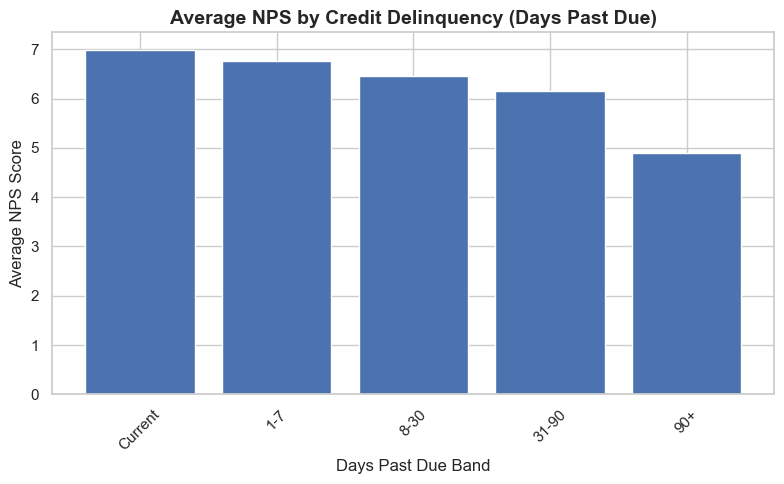

In [211]:
#load neccessary library
import matplotlib.pyplot as plt

#ensure numeric columns
df['nps_score'] = pd.to_numeric(df['nps_score'], errors='coerce')
df['days_past_due'] = pd.to_numeric(df['days_past_due'], errors='coerce')

#create NPS groups using pd.cut
#bins: 0-6 = Detractor, 7-8 = Passive, 9-10 = Promoter
nps_bins = [-1, 6, 8, 10]
nps_labels = ['Detractor', 'Passive', 'Promoter']
df['nps_group'] = pd.cut(df['nps_score'].fillna(-1), bins=nps_bins, labels=nps_labels, include_lowest=True)

#create days past due bands (ensure NaNs handled explicitly)
dpd_bins = [-1, 0, 7, 30, 90, np.inf]
dpd_labels = ['Current', '1-7', '8-30', '31-90', '90+']
df['dpd_band'] = pd.cut(df['days_past_due'].fillna(-1), bins=dpd_bins, labels=dpd_labels, include_lowest=True)

#aggregate mean NPS by DPD band
nps_by_dpd = df.groupby('dpd_band', observed=False)['nps_score'].mean().reset_index()

#plot
plt.figure(figsize=(8,5))
plt.bar(nps_by_dpd['dpd_band'].astype(str), nps_by_dpd['nps_score'])
plt.title("Average NPS by Credit Delinquency (Days Past Due)", fontsize=14, fontweight='bold')
plt.xlabel("Days Past Due Band")
plt.ylabel("Average NPS Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Operational Friction (Critical Insight)

- **Phone Lock Issue**

  phone_lock_issue  nps_score
0              N/A   6.365378
1               No   7.347914
2              Yes   5.866527


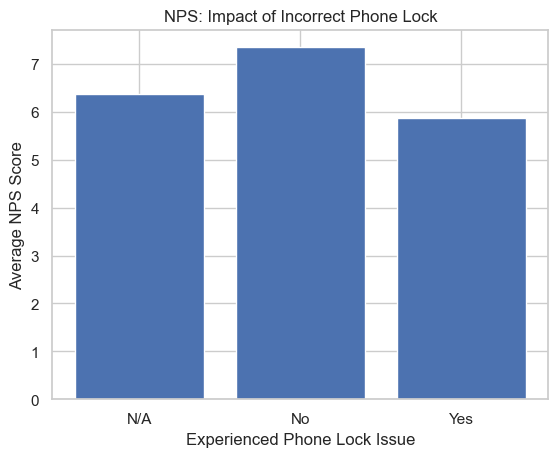

In [212]:
nps_phone_lock = df.groupby('phone_lock_issue')['nps_score'].mean().reset_index()
print(nps_phone_lock)

plt.figure()
plt.bar(nps_phone_lock['phone_lock_issue'].astype(str), nps_phone_lock['nps_score'])
plt.title("NPS: Impact of Incorrect Phone Lock")
plt.xlabel("Experienced Phone Lock Issue")
plt.ylabel("Average NPS Score")
plt.show()

- **Payment Delay Issue**

  payment_delay  nps_score
0           N/A   6.251569
1            No   7.330710
2           Yes   6.032337


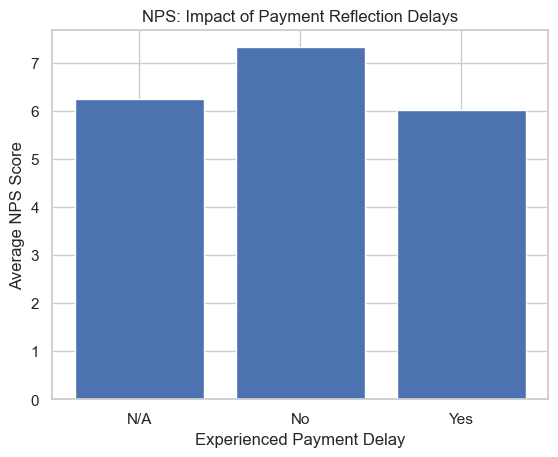

In [213]:
nps_payment_delay = df.groupby('payment_delay')['nps_score'].mean().reset_index()
print(nps_payment_delay)

plt.figure()
plt.bar(nps_payment_delay['payment_delay'].astype(str), nps_payment_delay['nps_score'])
plt.title("NPS: Impact of Payment Reflection Delays")
plt.xlabel("Experienced Payment Delay")
plt.ylabel("Average NPS Score")
plt.show()

#### The Core Tension

phone_lock_issue       N/A        No       Yes
dpd_band                                      
Current           6.890802  7.544158  6.027977
1-7               6.573222  7.166667  6.367925
8-30              5.933036  7.176768  6.168675
31-90             5.540453  7.097973  5.475806
90+               4.420202  6.157895  4.566327


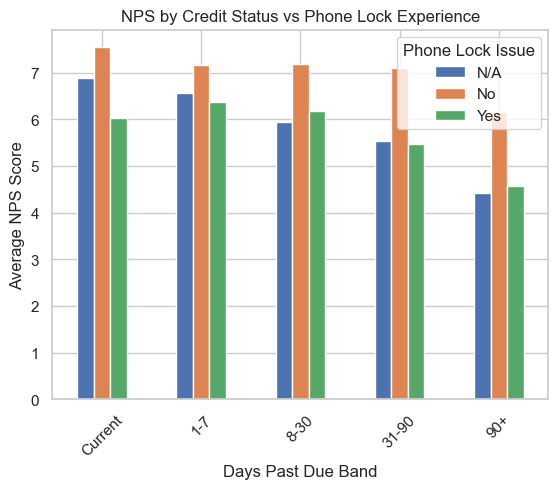

In [214]:
pivot_table = pd.pivot_table(
    df,
    values='nps_score',
    index='dpd_band',
    columns='phone_lock_issue',
    aggfunc='mean',
    observed=False 
)

print(pivot_table)

pivot_table.plot(kind='bar')
plt.title("NPS by Credit Status vs Phone Lock Experience")
plt.xlabel("Days Past Due Band")
plt.ylabel("Average NPS Score")
plt.xticks(rotation=45)
plt.legend(title="Phone Lock Issue")
plt.show()

### Insights
1. **NPS vs Credit Performance**: Customers with higher days_past_due tend to have lower NPS. Therefore, financial difficulty reduces satisfaction.

2. **Operational Friction (Critical Insight)**: 
Customers experiencing phone lock issues and payment delays show significantly lower NPS.

3. **The core tension**:
        - **Technical Stability as a Buffer**: Customers in the 8-30 day and 31-90 day arrears buckets who did not have lock issues (the orange bars) still maintain a relatively high NPS (above 7.0), suggesting that good technical performance preserves brand loyalty even when the customer is struggling financially.
        - **The "Lock" Penalty**: Across every single credit bucket, customers who experienced a "false lock" (phone locking despite on-time payment) have a lower Average NPS than those who did not.

### Recommendations
- **Refine Locking Logic**: Introduce a 2–6 hour "Validation Buffer" between payment and lock triggers to eliminate "False Locks" and preserve NPS among current and early-arrears customers.
- **Risk-Based Technical Support**: Prioritize "Unlock Support" for customers in the 31–90 day bucket; maintaining technical stability here acts as a buffer against total default and negative brand sentiment.
- **Service-Led Collections**: For the 1–30 day segment, pivot from aggressive collection to technical support outreach to ensure hardware issues aren't the root cause of non-payment.